<a href="https://colab.research.google.com/github/veerlaleelasrilekha/Sleep_Vs_Stress/blob/main/Titanic_advanced_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

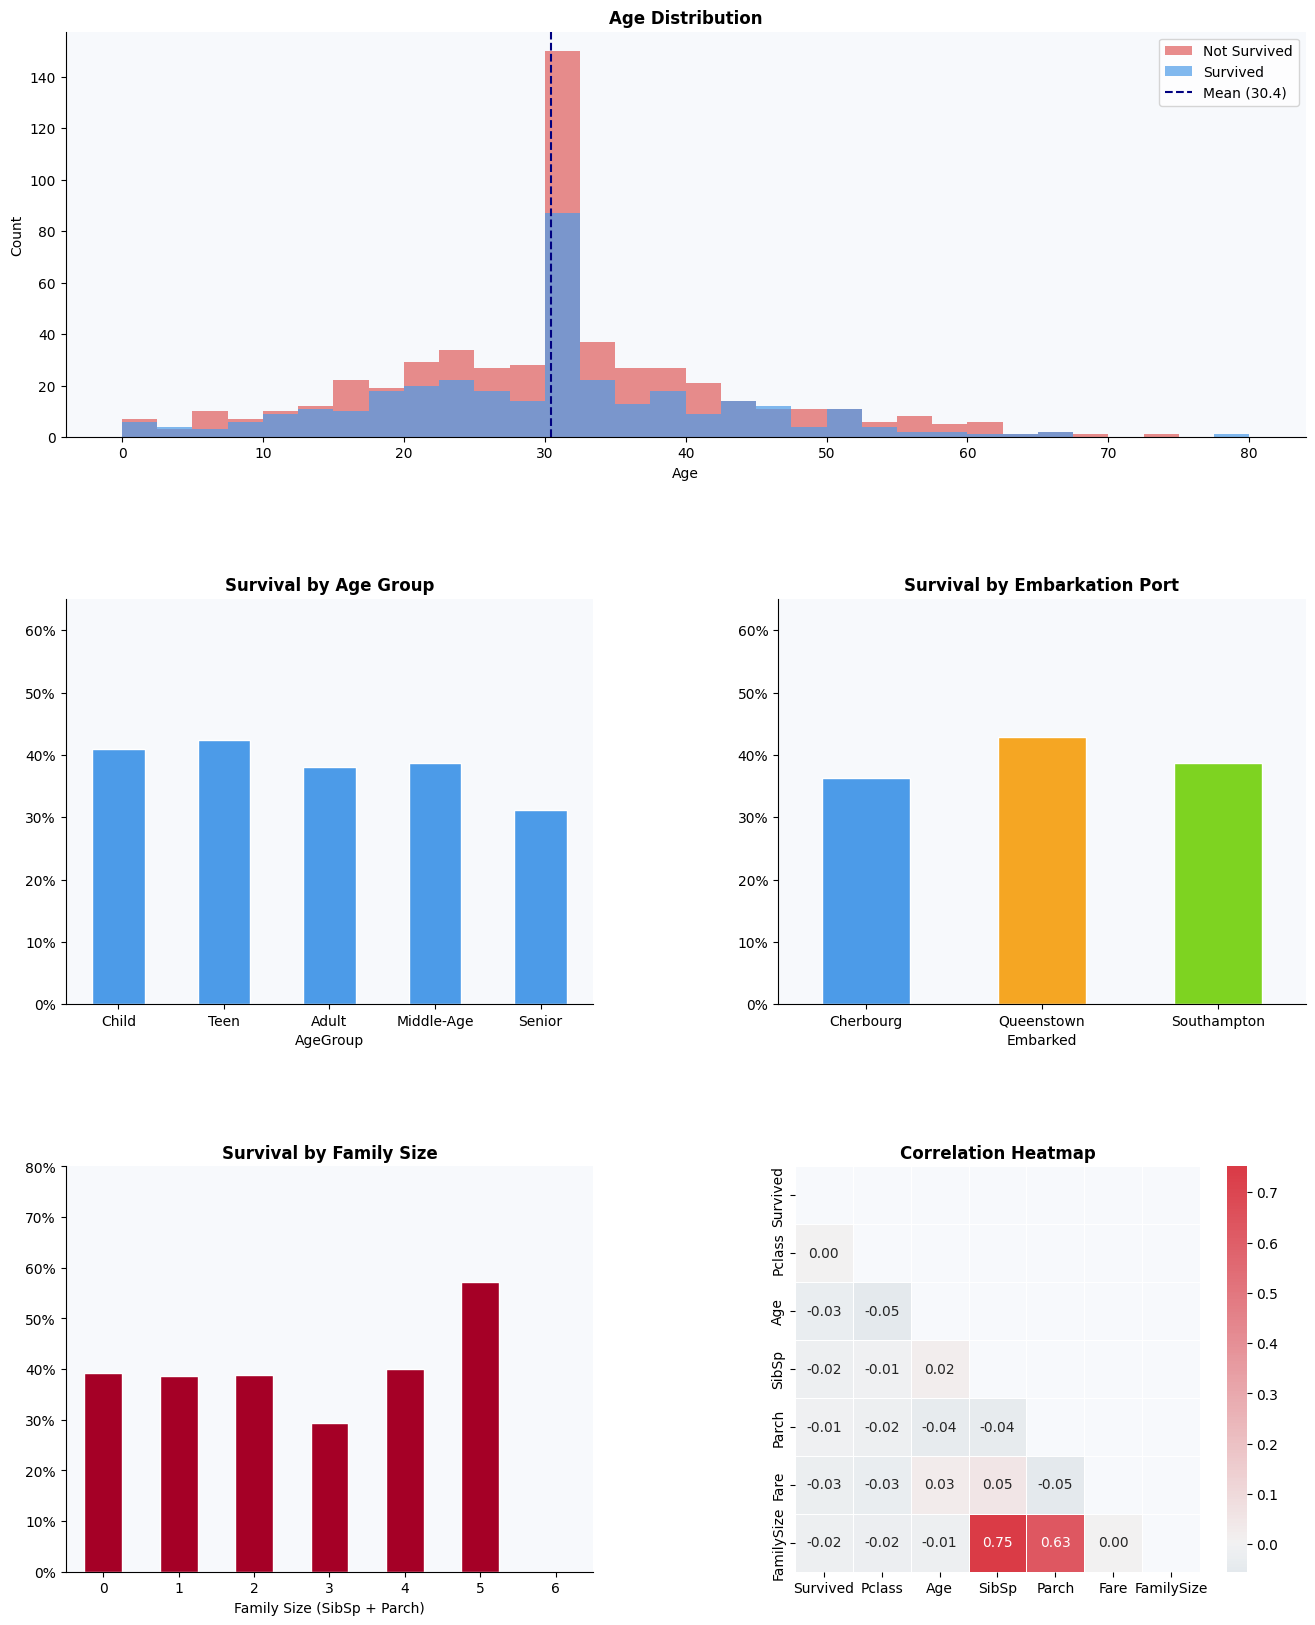

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# 1. LOAD (swap with pd.read_csv("test.csv") for real data)
np.random.seed(42)
n = 891
age_vals = np.random.normal(30, 14, n).clip(1, 80).astype(float)
age_vals[np.random.rand(n) < 0.2] = np.nan
df = pd.DataFrame({
    "Survived": np.random.choice([0,1], n, p=[0.62,0.38]),
    "Pclass":   np.random.choice([1,2,3], n, p=[0.24,0.21,0.55]),
    "Sex":      np.random.choice(["male","female"], n, p=[0.65,0.35]),
    "Age": age_vals,
    "SibSp": np.random.choice([0,1,2,3,4], n, p=[0.68,0.23,0.05,0.02,0.02]),
    "Parch": np.random.choice([0,1,2,3], n, p=[0.76,0.13,0.09,0.02]),
    "Fare":     np.random.exponential(33, n),
    "Embarked": np.random.choice(["S","C","Q"], n, p=[0.724,0.188,0.088]),
})

# 2. CLEAN
df["Age"] = df["Age"].fillna(df["Age"].mean())
df = df.dropna(subset=["Embarked"])

# 3. FEATURES
df["FamilySize"] = df["SibSp"] + df["Parch"]
df["AgeGroup"] = pd.cut(df["Age"], bins=[0,12,18,35,60,100],
    labels=["Child","Teen","Adult","Middle-Age","Senior"])

# 4. ANALYSIS
surv_age = df.groupby("AgeGroup", observed=True)["Survived"].mean()
surv_emb = df.groupby("Embarked")["Survived"].mean()
surv_fam = df.groupby("FamilySize")["Survived"].mean()

# 5. PLOTS
fig = plt.figure(figsize=(16, 20))
gs  = gridspec.GridSpec(3, 2, hspace=0.4, wspace=0.35)
BG, BLUE = "#F7F9FC", "#4C9BE8"

def style(ax, title):
    ax.set_facecolor(BG); ax.set_title(title, fontweight="bold")
    ax.spines[["top","right"]].set_visible(False)

# Histogram
ax = fig.add_subplot(gs[0,:])
style(ax, "Age Distribution")
bins = np.linspace(0, 80, 33)
ax.hist(df[df.Survived==0]["Age"], bins=bins, color="#E05C5C", alpha=0.7, label="Not Survived")
ax.hist(df[df.Survived==1]["Age"], bins=bins, color=BLUE,     alpha=0.7, label="Survived")
ax.axvline(df["Age"].mean(), color="navy", ls="--", label=f"Mean ({df['Age'].mean():.1f})")
ax.legend(); ax.set_xlabel("Age"); ax.set_ylabel("Count")

# Survival by Age Group
ax = fig.add_subplot(gs[1,0])
style(ax, "Survival by Age Group")
surv_age.mul(100).plot.bar(ax=ax, color=BLUE, edgecolor="white", rot=0)
ax.yaxis.set_major_formatter(PercentFormatter()); ax.set_ylim(0, 65)

# Survival by Embarkation
ax = fig.add_subplot(gs[1,1])
style(ax, "Survival by Embarkation Port")
surv_emb.rename({"S":"Southampton","C":"Cherbourg","Q":"Queenstown"}).mul(100)\
        .plot.bar(ax=ax, color=["#4C9BE8","#F5A623","#7ED321"], edgecolor="white", rot=0)
ax.yaxis.set_major_formatter(PercentFormatter()); ax.set_ylim(0, 65)

# Survival by Family Size
ax = fig.add_subplot(gs[2,0])
style(ax, "Survival by Family Size")
surv_fam.mul(100).plot.bar(ax=ax, colormap="RdYlGn", edgecolor="white", rot=0)
ax.yaxis.set_major_formatter(PercentFormatter()); ax.set_ylim(0, 80)
ax.set_xlabel("Family Size (SibSp + Parch)")

# Heatmap
ax = fig.add_subplot(gs[2,1])
style(ax, "Correlation Heatmap")
corr = df[["Survived","Pclass","Age","SibSp","Parch","Fare","FamilySize"]].corr()
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), ax=ax,
            cmap=sns.diverging_palette(240,10,as_cmap=True),
            center=0, annot=True, fmt=".2f", square=True, linewidths=0.5)

plt.savefig("titanic_analysis.png", dpi=150, bbox_inches="tight")
plt.show()